# 2026년 9월 7일 하루의 24시간 생활인구를 이용한 서울 대중교통 접근 취약지역 파일럿 분석

## 1. 분석 환경 설정

생활인구, 버스정류장, 철도역 데이터를 처리하고 공간적으로 분석하기 위해 필요한 라이브러리를 불러온다.

- `pandas`: 표 형태의 데이터 처리
- `geopandas`: 지도 및 공간데이터 처리
- `matplotlib`: 분석 결과 시각화

공간상의 거리와 주변 시설 수를 계산해야 하므로 일반적인 데이터 분석뿐 아니라 GeoPandas를 이용한 공간분석을 수행한다.

In [259]:
# 데이터 처리, 공간분석, 시각화에 필요한 라이브러리 불러오기
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [260]:
# 지도와 그래프에서 한글이 깨지지 않도록 나눔고딕 폰트 설정
!apt-get -qq install fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

# Matplotlib에 폰트 직접 등록
fm.fontManager.addfont(font_path)

# 폰트 이름 가져오기
font_name = fm.FontProperties(fname=font_path).get_name()

# 기본 폰트로 설정
plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

print("현재 설정된 폰트:", font_name)

현재 설정된 폰트: NanumGothic


## 2. 2026년 9월 7일 생활인구 데이터 불러오기

2026년 9월 7일 서울시 250m 격자별 생활인구 데이터를 불러온다.

이번 분석에서 필요한 변수만 선택한다.

- `일자`: 데이터 기준일
- `시간`: 0~23시 시간대
- `행정동코드`: 행정동 식별코드
- `250M격자`: 공간분석의 기본 단위
- `생활인구합계`: 해당 시간대의 생활인구

이번 분석은 전체 기간 분석에 앞서 분석 방법이 정상적으로 작동하는지 확인하기 위한 하루치 파일럿 분석이다.

In [261]:
# 2026년 9월 7일 생활인구 자료에서 분석에 필요한 열만 불러오기
pop = pd.read_csv(
    '/content/250_LOCAL_RESD_20260907.csv',
    encoding='cp949',
    usecols=['일자', '시간', '행정동코드', '250M격자', '생활인구합계']
)

pop.head()

,일자,시간,행정동코드,250M격자,생활인구합계
0,20260907,0,11110515,다사52255325,4.25
1,20260907,0,11110515,다사52255350,5.23
2,20260907,0,11110515,다사52255375,11.32
3,20260907,0,11110515,다사52505325,16.66
4,20260907,0,11110515,다사52505350,912.39


In [262]:
# 생활인구 값 중 숫자가 아닌 값은 계산할 수 있도록 NaN(결측값)으로 변환
pop['생활인구합계'] = pd.to_numeric(
    pop['생활인구합계'],
    errors='coerce'   # 숫자가 아닌 값은 NaN으로 처리
)

pop[['생활인구합계']].head()

,생활인구합계
0,4.25
1,5.23
2,11.32
3,16.66
4,912.39


## 3. 시간별 250m 격자 생활인구 정리

생활인구 원자료에서는 하나의 250m 격자가 행정동 경계와 겹쳐 여러 행으로 나타날 수 있다.

따라서 같은 시간대와 같은 250m 격자에 해당하는 생활인구를 먼저 합산하여,
각 시간별로 하나의 격자가 하나의 생활인구 값을 갖도록 정리한다.

이 과정을 통해 행정동 경계 때문에 동일 격자가 중복 처리되는 문제를 방지한다.

In [263]:
# 같은 시간·같은 250m 격자의 생활인구를 합산
hourly_grid = (
    pop.groupby(['시간', '250M격자'])['생활인구합계']
       .sum(min_count=1)
       .reset_index()
)

hourly_grid.head()

,시간,250M격자,생활인구합계
0,0,다사35005075,NaN
1,0,다사35005100,NaN
2,0,다사35255050,5.66
3,0,다사35255075,42.55
4,0,다사35255100,21.80


## 4. 격자별 하루 평균 생활인구 계산

시간별로 정리한 생활인구를 이용해 각 250m 격자의 하루 평균 생활인구를 계산한다.

여기서 `일평균생활인구`는 하루 동안 방문한 사람의 누적 인원이 아니라,
0~23시 각 시간대 생활인구의 평균값을 의미한다.

예를 들어 일평균생활인구가 3,000명이라면 하루 동안 3,000명이 방문했다는 뜻이 아니라,
각 시간대에 해당 공간에 존재한 생활인구가 평균적으로 약 3,000명이었다는 뜻이다.

In [264]:
# 각 격자의 시간별 생활인구 평균을 계산하여 일평균생활인구 생성
daily_pop = (
    hourly_grid.groupby('250M격자')['생활인구합계']
               .mean()
               .reset_index()
)

daily_pop = daily_pop.rename(
    columns={'생활인구합계': '일평균생활인구'}
)

daily_pop.head()

,250M격자,일평균생활인구
0,다사35005075,7.888235
1,다사35005100,NaN
2,다사35255050,11.371667
3,다사35255075,85.387083
4,다사35255100,43.681667


In [265]:
# 일평균생활인구의 분포와 생활인구가 특히 많은 격자를 확인
print(daily_pop['일평균생활인구'].describe())

daily_pop.sort_values('일평균생활인구', ascending=False).head(20)

count     8362.000000
mean      1310.827940
std       1542.587029
min          4.026667
25%         84.615313
50%        837.044792
75%       2096.298542
max      31039.423333
Name: 일평균생활인구, dtype: float64


,250M격자,일평균생활인구
4214,다사55755300,31039.423333
5314,다사58755100,24712.097500
3271,다사52255125,23441.040417
3671,다사53755250,17104.450833
686,다사42254800,12724.049583
8278,다사68254875,12078.206667
5002,다사58004425,11919.046250
637,다사42004650,11692.426667
7735,다사65254750,11161.255000
2247,다사49004725,11121.962500


## 5. 250m 격자 공간정보와 생활인구 결합

생활인구 데이터에는 250m 격자코드만 존재하므로 실제 지도상 위치와 연결하기 위해
서울시 250m 격자 공간정보(SHP)를 사용한다.

공간정보의 `CELL_ID`와 생활인구 데이터의 `250M격자`를 기준으로 결합한다.

이 과정을 통해 각 생활인구 격자의 실제 위치를 알 수 있고,
이후 버스정류장 및 철도역과의 거리와 주변 시설 수를 계산할 수 있다.

In [266]:
# 서울시 250m 격자 공간정보 압축파일 해제
!unzip -o "/content/서울생활인구_250m격자정보_EPSG5179.zip" -d "/content/grid250"

Archive:  /content/서울생활인구_250m격자정보_EPSG5179.zip
  inflating: /content/grid250/match/match.shp  
  inflating: /content/grid250/match/match.qix  
  inflating: /content/grid250/match/match.shx  
  inflating: /content/grid250/match/match.prj  
  inflating: /content/grid250/match/match.qmd  
  inflating: /content/grid250/match/match.cpg  
  inflating: /content/grid250/match/match.dbf  


In [267]:
# 압축 해제된 폴더에서 SHP 파일 위치 찾기
import glob

shp_files = glob.glob('/content/grid250/**/*.shp', recursive=True)
shp_files

['/content/grid250/match/match.shp']

In [268]:
# 250m 격자 SHP 파일을 GeoDataFrame으로 불러오기
grid = gpd.read_file(shp_files[0])

grid.head()

,CELL_ID,CELL_X,CELL_Y,GID,geometry
0,다사54504050,954625,1940625,다사54ba40ba,"POLYGON ((954500 1940500, 954500 1940750, 9547..."
1,다사54255675,954375,1956875,다사54ab56bb,"POLYGON ((954250 1956750, 954250 1957000, 9545..."
2,다사54255700,954375,1957125,다사54ab57aa,"POLYGON ((954250 1957000, 954250 1957250, 9545..."
3,다사54255725,954375,1957375,다사54ab57ab,"POLYGON ((954250 1957250, 954250 1957500, 9545..."
4,다사54255750,954375,1957625,다사54ab57ba,"POLYGON ((954250 1957500, 954250 1957750, 9545..."


In [269]:
# 격자코드를 기준으로 공간정보와 일평균 생활인구 결합
seoul = grid.merge(
    daily_pop,
    left_on='CELL_ID',
    right_on='250M격자',
    how='left'
)

seoul.head()

,CELL_ID,CELL_X,CELL_Y,GID,geometry,250M격자,일평균생활인구
0,다사54504050,954625,1940625,다사54ba40ba,"POLYGON ((954500 1940500, 954500 1940750, 9547...",다사54504050,201.590417
1,다사54255675,954375,1956875,다사54ab56bb,"POLYGON ((954250 1956750, 954250 1957000, 9545...",NaN,NaN
2,다사54255700,954375,1957125,다사54ab57aa,"POLYGON ((954250 1957000, 954250 1957250, 9545...",다사54255700,56.194583
3,다사54255725,954375,1957375,다사54ab57ab,"POLYGON ((954250 1957250, 954250 1957500, 9545...",다사54255725,8.873750
4,다사54255750,954375,1957625,다사54ab57ba,"POLYGON ((954250 1957500, 954250 1957750, 9545...",NaN,NaN


In [270]:
# 격자코드와 생활인구가 정상적으로 결합됐는지 일부 행 확인
seoul[['CELL_ID', '250M격자', '일평균생활인구']].head(10)

,CELL_ID,250M격자,일평균생활인구
0,다사54504050,다사54504050,201.590417
1,다사54255675,NaN,NaN
2,다사54255700,다사54255700,56.194583
3,다사54255725,다사54255725,8.873750
4,다사54255750,NaN,NaN
5,다사54255575,다사54255575,6.264167
6,다사54255600,다사54255600,191.082500
7,다사54255625,다사54255625,6.989167
8,다사54255650,다사54255650,6.648333
9,다사54255875,NaN,NaN


In [271]:
# 전체 격자 중 생활인구 데이터가 정상적으로 결합된 격자 수 확인
print('전체 격자 수:', len(seoul))
print('생활인구가 붙은 격자 수:', seoul['일평균생활인구'].notna().sum())
print('생활인구가 없는 격자 수:', seoul['일평균생활인구'].isna().sum())

전체 격자 수: 10125
생활인구가 붙은 격자 수: 8361
생활인구가 없는 격자 수: 1764


In [272]:
# 생활인구에는 존재하지만 SHP 공간정보와 매칭되지 않은 격자코드 확인
set(daily_pop['250M격자']) - set(grid['CELL_ID'])

{'다사47256125', '다사67254075'}

## 6. 생활인구 공간분포 시각화

250m 격자별 일평균 생활인구가 서울에서 어떻게 분포하는지 지도에 나타낸다.

일부 격자의 매우 큰 생활인구 값 때문에 나머지 지역의 색 차이가 보이지 않는 것을 방지하기 위해
시각화의 최대 색상값을 생활인구 95백분위수로 설정한다.

이는 실제 생활인구 값을 삭제하거나 변경하는 것이 아니라,
지도에서 색상을 표현하는 범위만 조정한 것이다.

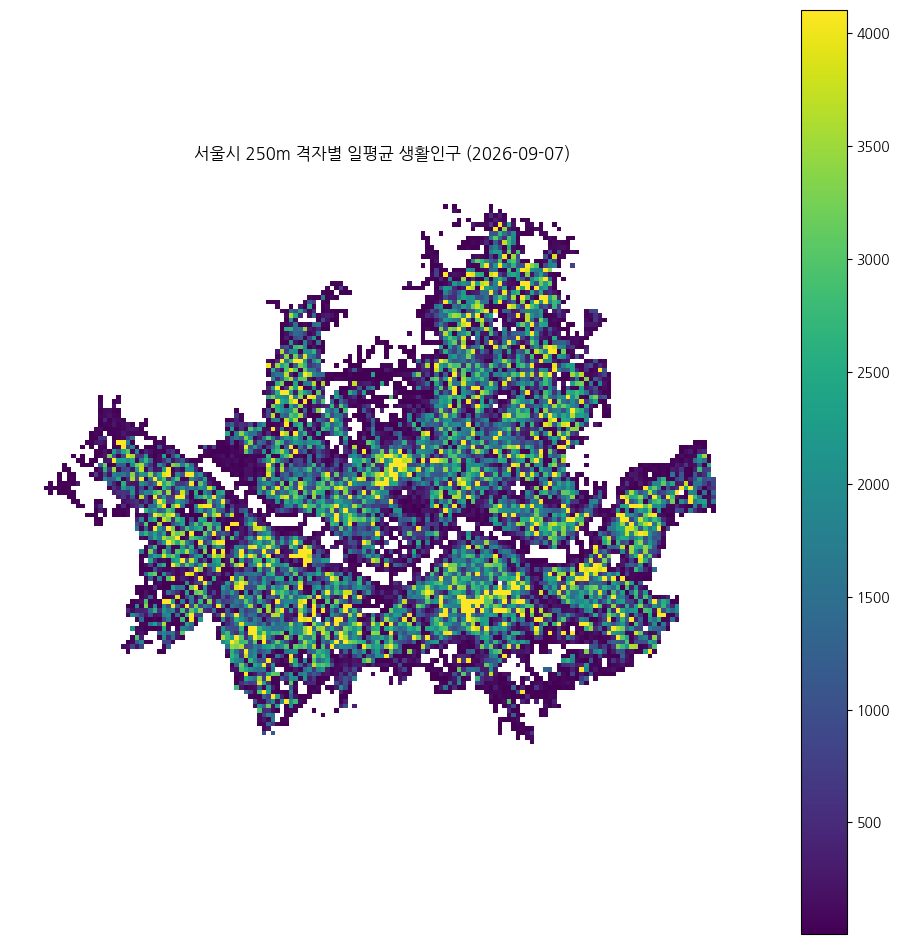

In [273]:
# 극단값 때문에 다른 지역의 색 차이가 사라지는 것을 막기 위해 95백분위수를 시각화 최대값으로 사용
vmax = seoul['일평균생활인구'].quantile(0.95)

fig, ax = plt.subplots(figsize=(12, 12))

seoul.plot(
    column='일평균생활인구',
    ax=ax,
    legend=True,
    vmax=vmax,
    missing_kwds={'alpha': 0}
)

ax.set_title('서울시 250m 격자별 일평균 생활인구 (2026-09-07)')
ax.axis('off')

plt.show()

## 7. 버스정류장 위치 데이터 전처리

서울시 버스정류소 위치정보를 이용해 각 생활인구 격자의 버스 접근성을 계산한다.

한강선착장은 일반적인 도로 기반 버스정류장과 성격이 다르므로 분석에서 제외한다.

버스정류장 원자료는 경도·위도 좌표계(EPSG:4326)를 사용하지만,
거리(m)를 계산하기 위해 서울 250m 격자와 같은 EPSG:5179 좌표계로 변환한다.

In [274]:
# 서울시 버스정류소 위치정보 불러오기
bus = pd.read_excel(
    '/content/서울시버스정류소위치정보(20260902).xlsx'
)

bus.head()

,NODE_ID,ARS_ID,정류소명,X좌표,Y좌표,정류소타입
0,123000689,1,한강버스.잠실선착장,127.084778,37.518944,한강선착장
1,104000315,2,한강버스.뚝섬선착장,127.066472,37.528695,한강선착장
2,103000517,3,한강버스.옥수선착장,127.018056,37.538750,한강선착장
3,122000752,4,한강버스.압구정선착장,127.016361,37.526806,한강선착장
4,118000622,5,한강버스.여의도선착장,126.934639,37.529000,한강선착장


In [275]:
# 버스정류장 데이터의 변수명 확인
bus.columns

Index(['NODE_ID', 'ARS_ID', '정류소명', 'X좌표', 'Y좌표', '정류소타입'], dtype='object')

In [276]:
# 일반적인 도로 대중교통 분석과 성격이 다른 한강선착장 제외
bus = bus[bus['정류소타입'] != '한강선착장'].copy()

bus['정류소타입'].value_counts()

,count
정류소타입,
일반차로,6251
마을버스,4175
중앙차로,405
가로변시간,256
가로변전일,141


In [277]:
# 버스정류장의 X·Y좌표를 이용해 공간데이터로 변환
bus_gdf = gpd.GeoDataFrame(
    bus,
    geometry=gpd.points_from_xy(
        bus['X좌표'],
        bus['Y좌표']
    ),
    crs='EPSG:4326'
)

bus_gdf.head()

,NODE_ID,ARS_ID,정류소명,X좌표,Y좌표,정류소타입,geometry
8,100000001,1001,종로2가사거리,126.987752,37.569806,중앙차로,POINT (126.98775 37.56981)
9,100000002,1002,창경궁.서울대학교병원,126.996521,37.579433,중앙차로,POINT (126.99652 37.57943)
10,100000003,1003,명륜3가.성대입구,126.998251,37.582580,중앙차로,POINT (126.99825 37.58258)
11,100000004,1004,종로2가.삼일교,126.987613,37.568579,중앙차로,POINT (126.98761 37.56858)
12,100000005,1005,혜화동로터리.여운형활동터,127.001744,37.586243,중앙차로,POINT (127.00174 37.58624)


In [278]:
# 거리(m) 계산을 위해 버스정류장 좌표계를 EPSG:5179로 변환
bus_gdf = bus_gdf.to_crs(epsg=5179)

In [279]:
# 버스정류장과 격자 데이터의 좌표계가 동일한지 확인
print(bus_gdf.crs)
print(grid.crs)

EPSG:5179
EPSG:5179


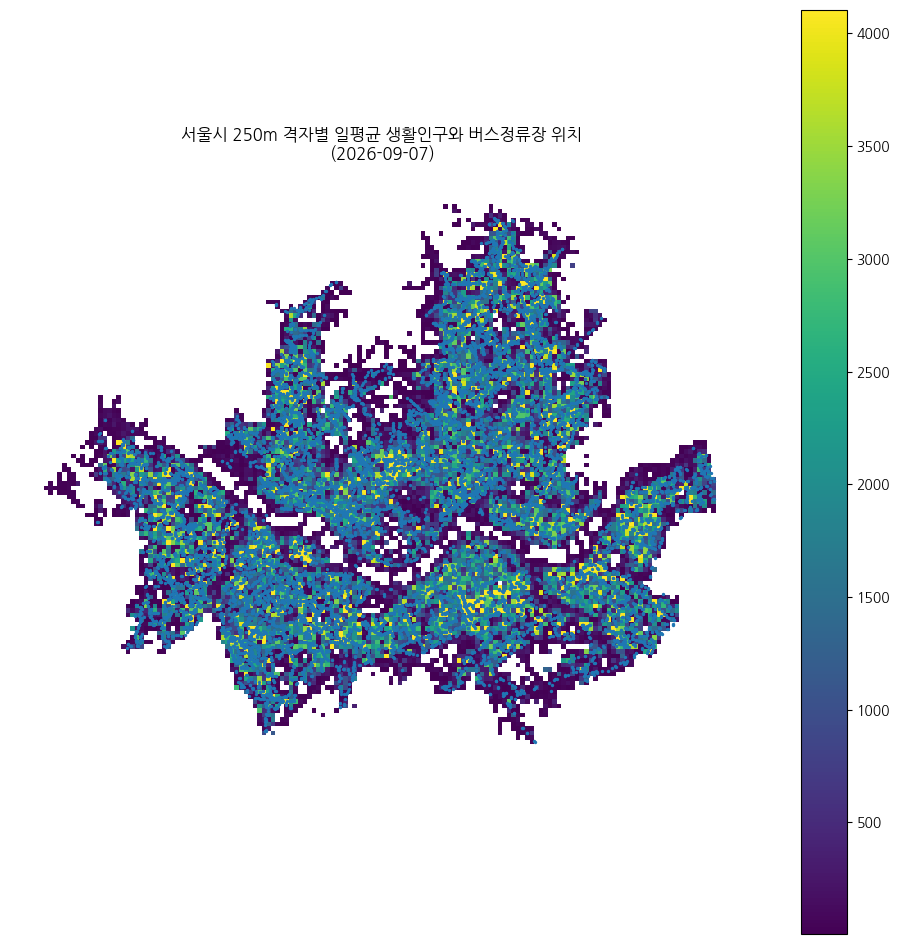

In [280]:
# 생활인구 격자와 버스정류장을 한 지도에 표시하여 좌표 변환이 정상적인지 확인
vmax = seoul['일평균생활인구'].quantile(0.95)

fig, ax = plt.subplots(figsize=(12, 12))

seoul.plot(
    column='일평균생활인구',
    ax=ax,
    legend=True,
    vmax=vmax,
    missing_kwds={'alpha': 0}
)

bus_gdf.plot(
    ax=ax,
    markersize=2
)

ax.set_title(
    '서울시 250m 격자별 일평균 생활인구와 버스정류장 위치\n'
    '(2026-09-07)'
)

ax.axis('off')

plt.show()

## 8. 격자별 500m 내 버스정류장 수 계산

각 250m 격자의 중심점을 접근성 측정 기준점으로 사용한다.

격자 중심에서 반경 500m의 공간(buffer)을 만든 뒤,
그 범위 안에 위치한 버스정류장 수를 계산한다.

이번 파일럿에서는 500m를 도보로 접근 가능한 버스정류장 생활권의 잠정 기준으로 사용한다.

주변 버스정류장이 많을수록 버스를 이용할 선택지가 많다고 보고,
정류장이 적을수록 상대적으로 버스 접근성이 취약하다고 판단한다.

In [281]:
# 각 250m 격자의 중심점 계산
seoul['center'] = seoul.geometry.centroid

In [282]:
# 격자 중심점이 정상적으로 생성됐는지 확인
seoul[['CELL_ID', 'geometry', 'center']].head()

,CELL_ID,geometry,center
0,다사54504050,"POLYGON ((954500 1940500, 954500 1940750, 9547...",POINT (954625 1940625)
1,다사54255675,"POLYGON ((954250 1956750, 954250 1957000, 9545...",POINT (954375 1956875)
2,다사54255700,"POLYGON ((954250 1957000, 954250 1957250, 9545...",POINT (954375 1957125)
3,다사54255725,"POLYGON ((954250 1957250, 954250 1957500, 9545...",POINT (954375 1957375)
4,다사54255750,"POLYGON ((954250 1957500, 954250 1957750, 9545...",POINT (954375 1957625)


In [283]:
# 각 격자 중심에서 반경 500m의 버스 접근권 생성
buffer_500 = gpd.GeoDataFrame(
    seoul[['CELL_ID', '일평균생활인구']].copy(),
    geometry=seoul['center'].buffer(500),
    crs=seoul.crs
)

buffer_500.head()

,CELL_ID,일평균생활인구,geometry
0,다사54504050,201.590417,"POLYGON ((955125 1940625, 955122.592 1940575.9..."
1,다사54255675,NaN,"POLYGON ((954875 1956875, 954872.592 1956825.9..."
2,다사54255700,56.194583,"POLYGON ((954875 1957125, 954872.592 1957075.9..."
3,다사54255725,8.873750,"POLYGON ((954875 1957375, 954872.592 1957325.9..."
4,다사54255750,NaN,"POLYGON ((954875 1957625, 954872.592 1957575.9..."


In [284]:
# 각 500m 접근권 안에 포함되는 버스정류장을 공간결합으로 찾기
joined = gpd.sjoin(
    bus_gdf,
    buffer_500,
    how='inner',
    predicate='within'
)

joined.head()

,NODE_ID,ARS_ID,정류소명,X좌표,Y좌표,정류소타입,geometry,index_right,CELL_ID,일평균생활인구
8,100000001,1001,종로2가사거리,126.987752,37.569806,중앙차로,POINT (954764.414 1952394.075),9874,다사55005200,899.575417
8,100000001,1001,종로2가사거리,126.987752,37.569806,중앙차로,POINT (954764.414 1952394.075),9875,다사55005225,3830.128333
8,100000001,1001,종로2가사거리,126.987752,37.569806,중앙차로,POINT (954764.414 1952394.075),9876,다사55005250,2892.573333
8,100000001,1001,종로2가사거리,126.987752,37.569806,중앙차로,POINT (954764.414 1952394.075),9902,다사54755200,4223.382917
8,100000001,1001,종로2가사거리,126.987752,37.569806,중앙차로,POINT (954764.414 1952394.075),9903,다사54755225,3644.118750


In [285]:
# 동일 정류장의 중복을 방지하기 위해 NODE_ID 기준 고유 정류장 수 계산
bus_count = (
    joined.groupby('CELL_ID')['NODE_ID']
          .nunique()
          .reset_index(name='500m_내_버스정류장수')
)

bus_count.head(10)

,CELL_ID,500m_내_버스정류장수
0,다사37504850,1
1,다사37504875,2
2,다사37504900,2
3,다사37504925,1
4,다사37505150,2
5,다사37505175,2
6,다사37505300,1
7,다사37505325,2
8,다사37505350,3
9,다사37505375,2


In [286]:
# 계산한 500m 내 버스정류장 수를 서울 격자 데이터에 결합
seoul = seoul.merge(
    bus_count,
    on='CELL_ID',
    how='left'
)

In [287]:
# 500m 안에 버스정류장이 하나도 없는 격자는 0개로 처리
seoul['500m_내_버스정류장수'] = (
    seoul['500m_내_버스정류장수']
    .fillna(0)
    .astype(int)
)

In [288]:
# 생활인구와 500m 내 버스정류장 수가 정상적으로 결합됐는지 확인
seoul[
    ['CELL_ID', '일평균생활인구', '500m_내_버스정류장수']
].head(20)

,CELL_ID,일평균생활인구,500m_내_버스정류장수
0,다사54504050,201.590417,2
1,다사54255675,NaN,3
2,다사54255700,56.194583,6
3,다사54255725,8.873750,7
4,다사54255750,NaN,5
5,다사54255575,6.264167,0
6,다사54255600,191.082500,0
7,다사54255625,6.989167,0
8,다사54255650,6.648333,0
9,다사54255875,NaN,0


In [289]:
# 서울 전체 격자의 500m 내 버스정류장 수 분포 확인
seoul['500m_내_버스정류장수'].describe()

,500m_내_버스정류장수
count,10125.000000
mean,13.880691
std,11.259457
min,0.000000
25%,3.000000
50%,13.000000
75%,22.000000
max,68.000000


In [290]:
# 생활인구가 존재하는 지역 중 버스정류장이 적고 생활인구가 많은 격자를 우선 확인
seoul[
    seoul['일평균생활인구'].notna()
].sort_values(
    ['500m_내_버스정류장수', '일평균생활인구'],
    ascending=[True, False]
)[
    ['CELL_ID', '일평균생활인구', '500m_내_버스정류장수']
].head(20)

,CELL_ID,일평균생활인구,500m_내_버스정류장수
42,다사54005575,2953.095833,0
8486,다사58254825,2150.762500,0
6596,다사62504075,1314.293333,0
5335,다사43755300,1223.853333,0
6478,다사62754075,1163.442500,0
7259,다사61005375,1148.652500,0
4807,다사46255125,1142.384583,0
1762,다사64004375,1018.556250,0
153,다사53754775,978.954583,0
6798,다사62004625,957.365417,0


## 9. 가장 가까운 버스정류장 거리 계산

주변 버스정류장 수만으로는 실제 접근성을 충분히 설명하기 어렵다.

따라서 각 격자의 중심점에서 가장 가까운 버스정류장까지의 거리도 함께 계산한다.

현재 계산되는 거리는 실제 도로를 따라 걷는 도보거리가 아니라
공간 좌표상 직선거리이며, 취약지역을 1차적으로 선별하기 위한 지표로 사용한다.

In [291]:
# 최근접 거리 계산을 위해 격자 중심점을 GeoDataFrame으로 생성
grid_center = gpd.GeoDataFrame(
    seoul[['CELL_ID', '일평균생활인구', '500m_내_버스정류장수']].copy(),
    geometry=seoul['center'],
    crs=seoul.crs
)

grid_center.head()

,CELL_ID,일평균생활인구,500m_내_버스정류장수,geometry
0,다사54504050,201.590417,2,POINT (954625 1940625)
1,다사54255675,NaN,3,POINT (954375 1956875)
2,다사54255700,56.194583,6,POINT (954375 1957125)
3,다사54255725,8.873750,7,POINT (954375 1957375)
4,다사54255750,NaN,5,POINT (954375 1957625)


In [292]:
# 각 격자 중심에서 가장 가까운 버스정류장과 직선거리 계산
nearest_bus = gpd.sjoin_nearest(
    grid_center,
    bus_gdf[['NODE_ID', '정류소명', 'geometry']],
    how='left',
    distance_col='가장가까운_버스정류장거리_m'
)

nearest_bus.head()

,CELL_ID,일평균생활인구,500m_내_버스정류장수,geometry,index_right,NODE_ID,정류소명,가장가까운_버스정류장거리_m
0,다사54504050,201.590417,2,POINT (954625 1940625),8673,120000061,남태령역,219.541769
1,다사54255675,NaN,3,POINT (954375 1956875),329,100900124,형제봉입구,322.327704
2,다사54255700,56.194583,6,POINT (954375 1957125),329,100900124,형제봉입구,129.612595
3,다사54255725,8.873750,7,POINT (954375 1957375),329,100900124,형제봉입구,233.888223
4,다사54255750,NaN,5,POINT (954375 1957625),319,100900134,감람산기도원,298.379396


In [293]:
# 동일한 최소거리의 정류장이 여러 개 검색되는 경우 격자당 한 행만 유지
nearest_bus = (
    nearest_bus
    .sort_values('가장가까운_버스정류장거리_m')
    .drop_duplicates(subset='CELL_ID')
)

nearest_bus.head()

,CELL_ID,일평균생활인구,500m_내_버스정류장수,geometry,index_right,NODE_ID,정류소명,가장가까운_버스정류장거리_m
4089,다사48255350,2174.761667,29,POINT (948375 1953625),4990,112000184,DMC두산위브아파트,1.041450
399,다사53254325,2341.271250,31,POINT (953375 1943375),8433,119900182,대림아파트후문.래미안로이파크,1.861094
8408,다사58505825,3975.767917,34,POINT (958625 1958375),3416,108900271,달팽이계단,2.300689
824,다사67504975,4371.191667,20,POINT (967625 1949875),11130,124900075,서울.경기양돈농협,2.355406
3525,다사50004600,2466.096250,16,POINT (950125 1946125),8181,119000023,KT동작지사,2.844567


In [294]:
# 가장 가까운 버스정류장 거리의 전체 분포 확인
nearest_bus['가장가까운_버스정류장거리_m'].describe()

,가장가까운_버스정류장거리_m
count,10125.000000
mean,317.132507
std,401.356768
min,1.041450
25%,90.280961
50%,168.051585
75%,363.291655
max,3131.876749


In [295]:
# 최근접 버스정류장 거리를 서울 격자 데이터에 결합
bus_distance = nearest_bus[
    ['CELL_ID', '가장가까운_버스정류장거리_m']
].copy()

seoul = seoul.merge(
    bus_distance,
    on='CELL_ID',
    how='left'
)

seoul[
    [
        'CELL_ID',
        '일평균생활인구',
        '500m_내_버스정류장수',
        '가장가까운_버스정류장거리_m'
    ]
].head()

,CELL_ID,일평균생활인구,500m_내_버스정류장수,가장가까운_버스정류장거리_m
0,다사54504050,201.590417,2,219.541769
1,다사54255675,NaN,3,322.327704
2,다사54255700,56.194583,6,129.612595
3,다사54255725,8.873750,7,233.888223
4,다사54255750,NaN,5,298.379396


In [296]:
# 500m 안에 정류장이 없는 지역 중 생활인구가 높은 격자를 추가 확인
seoul[
    (seoul['500m_내_버스정류장수'] == 0) &
    (seoul['일평균생활인구'].notna())
][
    [
        'CELL_ID',
        '일평균생활인구',
        '500m_내_버스정류장수',
        '가장가까운_버스정류장거리_m'
    ]
].sort_values(
    '일평균생활인구',
    ascending=False
).head(20)

,CELL_ID,일평균생활인구,500m_내_버스정류장수,가장가까운_버스정류장거리_m
42,다사54005575,2953.095833,0,861.567125
8486,다사58254825,2150.762500,0,599.323767
6596,다사62504075,1314.293333,0,746.638261
5335,다사43755300,1223.853333,0,1224.961877
6478,다사62754075,1163.442500,0,617.260466
7259,다사61005375,1148.652500,0,500.624698
4807,다사46255125,1142.384583,0,538.121914
1762,다사64004375,1018.556250,0,517.140348
153,다사53754775,978.954583,0,643.058976
6798,다사62004625,957.365417,0,512.929795


## 10. 철도역 접근성 계산

버스뿐 아니라 철도 접근성도 함께 반영하기 위해 서울시 역사마스터 데이터를 사용한다.

역사마스터에는 지하철뿐 아니라 일반철도 및 도시철도 등의 역사가 포함되어 있으므로,
본 분석에서는 이를 통틀어 '철도역 접근성'으로 해석한다.

버스와 마찬가지로 다음 두 가지 지표를 사용한다.

1. 가장 가까운 철도역까지의 거리
2. 격자 중심 반경 1km 내 철도역 수

철도역은 버스정류장보다 공간적으로 밀도가 낮기 때문에
이번 파일럿에서는 1km를 주변 철도역 접근권의 잠정 기준으로 사용한다.

In [297]:
# 서울시 역사마스터 데이터 불러오기
subway = pd.read_csv(
    '/content/서울시 역사마스터 정보.csv',
    encoding='cp949'
)

subway.head()

,역사_ID,역사명,호선,위도,경도
0,9010,동탄,수도권 광역급행철도,37.20034,127.09569
1,9009,구성,수도권 광역급행철도,37.29913,127.10389
2,9008,성남,수도권 광역급행철도,37.39467,127.12058
3,9007,수서,수도권 광역급행철도,37.48637,127.10161
4,9006,삼성,수도권 광역급행철도,37.50887,127.06324


In [298]:
# 철도역 위도·경도를 공간데이터로 변환하고 EPSG:5179로 좌표계 변경
subway_gdf = gpd.GeoDataFrame(
    subway,
    geometry=gpd.points_from_xy(
        subway['경도'],
        subway['위도']
    ),
    crs='EPSG:4326'
)

subway_gdf = subway_gdf.to_crs(epsg=5179)

subway_gdf.head()

,역사_ID,역사명,호선,위도,경도,geometry
0,9010,동탄,수도권 광역급행철도,37.20034,127.09569,POINT (964120.607 1911358.633)
1,9009,구성,수도권 광역급행철도,37.29913,127.10389,POINT (964894.159 1922315.189)
2,9008,성남,수도권 광역급행철도,37.39467,127.12058,POINT (966415.922 1932908.37)
3,9007,수서,수도권 광역급행철도,37.48637,127.10161,POINT (964779.804 1943088.694)
4,9006,삼성,수도권 광역급행철도,37.50887,127.06324,POINT (961399.221 1945599.967)


In [299]:
# 각 격자 중심에서 가장 가까운 철도역과 직선거리 계산
nearest_subway = gpd.sjoin_nearest(
    grid_center,
    subway_gdf[['역사명', '호선', 'geometry']],
    how='left',
    distance_col='가장가까운_철도역거리_m'
)

nearest_subway = (
    nearest_subway
    .sort_values('가장가까운_철도역거리_m')
    .drop_duplicates(subset='CELL_ID')
)

nearest_subway[
    [
        'CELL_ID',
        '일평균생활인구',
        '역사명',
        '호선',
        '가장가까운_철도역거리_m'
    ]
].head(10)

,CELL_ID,일평균생활인구,역사명,호선,가장가까운_철도역거리_m
6191,다사38255150,965.797917,김포공항,9호선,7.297703
5650,다사42004400,1898.011250,오류동,경인선,8.634874
1647,다사64254475,1887.735000,석촌고분,9호선(연장),13.815902
869,다사67254625,137.323750,올림픽공원(한국체대),5호선,15.693730
5783,다사41255000,4774.620417,우장산,5호선,18.728362
5281,다사43754750,2762.015417,목동,5호선,20.383627
301,다사53255075,836.173333,서울역,1호선,20.427461
4517,다사47005300,47.477917,디지털미디어시티,6호선,21.957770
5453,다사43254400,2148.409167,개봉,경인선,23.437047
5229,다사44254425,230.502917,구일,경인선,23.628610


In [300]:
# 가장 가까운 철도역 거리의 전체 분포 확인
nearest_subway['가장가까운_철도역거리_m'].describe()

,가장가까운_철도역거리_m
count,10125.000000
mean,869.347069
std,661.778708
min,7.297703
25%,402.270991
50%,667.137177
75%,1141.786667
max,3833.309354


In [301]:
# 최근접 철도역 이름·노선·거리를 서울 격자 데이터에 결합
subway_distance = nearest_subway[
    [
        'CELL_ID',
        '역사명',
        '호선',
        '가장가까운_철도역거리_m'
    ]
].copy()

seoul = seoul.merge(
    subway_distance,
    on='CELL_ID',
    how='left'
)

In [302]:
# 철도역은 버스정류장보다 밀도가 낮기 때문에 반경 1km를 파일럿 접근권으로 설정
# 격자 중심 기준 1km 반경 생성
rail_buffer_1000 = gpd.GeoDataFrame(
    seoul[['CELL_ID']].copy(),
    geometry=seoul['center'].buffer(1000),
    crs=seoul.crs
)

# 1km 안에 들어오는 철도역 찾기
rail_joined = gpd.sjoin(
    subway_gdf[['역사명', 'geometry']],
    rail_buffer_1000,
    how='inner',
    predicate='within'
)

# 1km 내 철도역 수 계산
rail_count = (
    rail_joined
    .groupby('CELL_ID')['역사명']
    .nunique()   # 환승역이 여러 호선으로 중복되어도 같은 역사명은 하나의 역으로 계산
    .reset_index(name='1km_내_철도역수')
)

# seoul에 붙이기
seoul = seoul.merge(
    rail_count,
    on='CELL_ID',
    how='left'
)

# 철도역이 하나도 없는 곳은 0
seoul['1km_내_철도역수'] = (
    seoul['1km_내_철도역수']
    .fillna(0)
    .astype(int)
)

seoul['1km_내_철도역수'].describe()

,1km_내_철도역수
count,10125.000000
mean,1.575309
std,1.476466
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,8.000000


In [303]:
# 버스·철도 접근성 지표가 격자 데이터에 정상적으로 추가됐는지 종합 확인
seoul[
    [
        'CELL_ID',
        '일평균생활인구',
        '500m_내_버스정류장수',
        '가장가까운_버스정류장거리_m',
        '1km_내_철도역수',
        '역사명',
        '호선',
        '가장가까운_철도역거리_m'
    ]
].head(20)

,CELL_ID,일평균생활인구,500m_내_버스정류장수,가장가까운_버스정류장거리_m,1km_내_철도역수,역사명,호선,가장가까운_철도역거리_m
0,다사54504050,201.590417,2,219.541769,1,남태령,4호선,198.245267
1,다사54255675,NaN,3,322.327704,0,북한산보국문,우이신설선,2233.033852
2,다사54255700,56.194583,6,129.612595,0,북한산보국문,우이신설선,2224.770351
3,다사54255725,8.873750,7,233.888223,0,북한산보국문,우이신설선,2244.496835
4,다사54255750,NaN,5,298.379396,0,북한산보국문,우이신설선,2291.490557
5,다사54255575,6.264167,0,612.572273,0,한성대입구(삼선교),4호선,2478.516923
6,다사54255600,191.082500,0,685.770242,0,북한산보국문,우이신설선,2418.047021
7,다사54255625,6.989167,0,719.679939,0,북한산보국문,우이신설선,2331.333165
8,다사54255650,6.648333,0,523.036201,0,북한산보국문,우이신설선,2268.981546
9,다사54255875,NaN,0,1308.679606,0,솔샘,우이신설선,2848.455326


## 11. 생활인구 상위 25% 지역 선별

대중교통 접근성이 낮더라도 실제 이용 수요가 거의 없는 산지·공원·외곽지역을
우선적인 정책 대상지역으로 선정하는 것은 의미가 제한적일 수 있다.

따라서 생활인구가 상대적으로 많은 지역을 먼저 후보지역으로 선정한 뒤
그 안에서 대중교통 접근성이 취약한 지역을 찾는다.

여러 분위수 기준을 비교한 후 이번 파일럿에서는
일평균 생활인구가 상위 25%에 해당하는 격자를 분석 후보로 사용한다.

상위 25% 기준은 파일럿 분석의 잠정 기준이며,
최종 분석에서는 다른 기준에서도 결과가 유지되는지 추가 검토할 필요가 있다.

In [304]:
# 생활인구 분포의 주요 분위수를 확인하여 후보지역 기준 검토
seoul['일평균생활인구'].quantile(
    [0.5, 0.7, 0.75, 0.8, 0.9]
)

,일평균생활인구
0.50,837.190833
0.70,1841.757500
0.75,2096.338750
0.80,2399.405417
0.90,3289.481250


In [305]:
# 상위 30%, 25%, 20%, 10% 기준값과 해당 격자 수 비교
for q in [0.70, 0.75, 0.80, 0.90]:
    cutoff = seoul['일평균생활인구'].quantile(q)
    count = (seoul['일평균생활인구'] >= cutoff).sum()

    print(
        f'상위 {round((1-q)*100)}% : '
        f'기준 {cutoff:.1f}명 / {count}개 격자'
    )

상위 30% : 기준 1841.8명 / 2509개 격자
상위 25% : 기준 2096.3명 / 2091개 격자
상위 20% : 기준 2399.4명 / 1673개 격자
상위 10% : 기준 3289.5명 / 837개 격자


In [306]:
# 이번 파일럿 분석에서는 생활인구 상위 25% 격자를 후보지역으로 선정
pop_cutoff = seoul['일평균생활인구'].quantile(0.75)

high_pop = seoul[
    seoul['일평균생활인구'] >= pop_cutoff
].copy()

print('생활인구 상위 25% 기준:', round(pop_cutoff, 1), '명')
print('선정된 격자 수:', len(high_pop))

생활인구 상위 25% 기준: 2096.3 명
선정된 격자 수: 2091


In [307]:
# 생활인구 상위 25% 후보지역의 1km 내 철도역 수 분포 확인
high_pop['1km_내_철도역수'].describe()

,1km_내_철도역수
count,2091.000000
mean,2.481110
std,1.481304
min,0.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,8.000000


In [308]:
# 후보지역의 생활인구와 주요 대중교통 접근성 지표 분포 확인
high_pop[
    [
        '일평균생활인구',
        '500m_내_버스정류장수',
        '가장가까운_버스정류장거리_m',
        '가장가까운_철도역거리_m'
    ]
].describe()

,일평균생활인구,500m_내_버스정류장수,가장가까운_버스정류장거리_m,가장가까운_철도역거리_m
count,2091.000000,2091.000000,2091.000000,2091.000000
mean,3392.398885,22.304161,109.444367,493.610768
std,1555.755966,8.979577,70.130198,334.652628
min,2096.338750,0.000000,1.041450,18.728362
25%,2473.160625,16.000000,59.370483,266.411505
50%,3031.052917,21.000000,95.283336,430.820628
75%,3831.016458,28.000000,145.149520,620.845193
max,31039.423333,65.000000,861.567125,3187.663798


## 12. 대중교통 접근 취약점수 산정

버스정류장 수, 철도역 수, 거리처럼 단위가 서로 다른 지표를 하나의 점수로 결합하기 위해
생활인구 상위 25% 후보지역 안에서 각 지표를 백분위 순위(`rank(pct=True)`)로 변환한다.

취약성의 방향은 다음과 같다.

- 500m 내 버스정류장 수: 적을수록 취약
- 가장 가까운 버스정류장 거리: 멀수록 취약
- 1km 내 철도역 수: 적을수록 취약
- 가장 가까운 철도역 거리: 멀수록 취약

버스 접근성은 '정류장 수 + 최근접 정류장 거리'의 평균,
철도 접근성은 '철도역 수 + 최근접 철도역 거리'의 평균으로 계산한다.

최종적으로 버스 접근성과 철도 접근성을 각각 50% 반영하므로
네 개의 세부 지표가 각각 25%씩 반영된다.

대중교통 접근취약점수가 1에 가까울수록
후보지역들 가운데 상대적으로 대중교통 접근성이 취약하다는 의미이며,
절대적인 취약 확률을 의미하지 않는다.

In [309]:
# 서로 단위가 다른 네 지표를 후보지역 내 백분위 순위로 변환
# 버스정류장 수가 적을수록 취약
high_pop['버스정류장수_취약점수'] = (
    1 - high_pop['500m_내_버스정류장수'].rank(pct=True)
)

# 가장 가까운 버스정류장이 멀수록 취약
high_pop['버스거리_취약점수'] = (
    high_pop['가장가까운_버스정류장거리_m'].rank(pct=True)
)

# 1km 안에 철도역이 적을수록 취약
high_pop['철도역수_취약점수'] = (
    1 - high_pop['1km_내_철도역수'].rank(pct=True)
)

# 가장 가까운 철도역이 멀수록 취약
high_pop['철도거리_취약점수'] = (
    high_pop['가장가까운_철도역거리_m'].rank(pct=True)
)

In [310]:
# 버스정류장 수와 최근접 정류장 거리를 동일하게 반영하여 버스 접근 취약점수 계산
high_pop['버스접근취약점수'] = (
    high_pop['버스정류장수_취약점수'] +
    high_pop['버스거리_취약점수']
) / 2

In [311]:
# 버스와 철도 접근취약점수를 각각 50% 반영
# 결과적으로 네 세부 지표는 각각 25%씩 최종 점수에 반영됨
# 철도 접근 취약점수
high_pop['철도접근취약점수'] = (
    high_pop['철도역수_취약점수'] +
    high_pop['철도거리_취약점수']
) / 2

# 최종 대중교통 접근 취약점수
high_pop['대중교통_접근취약점수'] = (
    high_pop['버스접근취약점수'] +
    high_pop['철도접근취약점수']
) / 2

## 13. 취약지역 후보의 공간적 중복 제거 및 TOP 10 선정

250m 격자를 단순히 취약점수 순으로 정렬하면
하나의 취약지역 주변의 여러 인접 격자가 TOP 10을 동시에 차지할 수 있다.

이 경우 실제로는 같은 생활권을 여러 개의 독립된 취약지역처럼 제시하게 된다.

이를 방지하기 위해 취약점수가 높은 격자부터 순서대로 확인하면서,
이미 선정된 후보와 중심점 기준 1km 이상 떨어진 경우에만 새로운 후보로 선정한다.

1km 기준은 버스 접근권을 반경 500m로 설정했을 때
두 격자 중심 사이의 거리가 1km보다 가까우면 접근권이 서로 겹칠 수 있다는 점을 고려한 잠정 기준이다.

이 과정을 통해 서로 다른 생활권을 대표하는 10개의 후보지역을 선정한다.

In [312]:
# 취약점수가 높은 순서대로 확인하면서 서로 1km 이상 떨어진 후보만 선택
# 생활인구 상위 25% 후보를 취약점수 높은 순으로 정렬
candidates = high_pop.sort_values(
    '대중교통_접근취약점수',
    ascending=False
).copy()

selected = []

for idx, row in candidates.iterrows():

    center = row.geometry.centroid

    # 아직 아무 후보도 선정되지 않았다면 바로 추가
    if len(selected) == 0:
        selected.append(row)
        continue

    # 이미 선정된 후보들과의 거리 계산
    distances = [
        center.distance(selected_row.geometry.centroid)
        for selected_row in selected
    ]

    # 모든 기존 후보와 1km 이상 떨어져 있으면 선정
    if min(distances) >= 1000:
        selected.append(row)

    # 10개가 채워지면 종료
    if len(selected) == 10:
        break

In [313]:
# 선정된 10개 후보를 공간데이터로 만들고 최종 순위 부여
top10_unique = gpd.GeoDataFrame(
    selected,
    crs=high_pop.crs
).reset_index(drop=True)

top10_unique['순위'] = range(1, len(top10_unique) + 1)

In [314]:
# 공간 중복 제거 후 최종 TOP 10의 주요 지표 확인
top10_unique[
    [
        '순위',
        'CELL_ID',
        '일평균생활인구',
        '500m_내_버스정류장수',
        '가장가까운_버스정류장거리_m',
        '1km_내_철도역수',
        '가장가까운_철도역거리_m',
        '대중교통_접근취약점수'
    ]
]

,순위,CELL_ID,일평균생활인구,500m_내_버스정류장수,가장가까운_버스정류장거리_m,1km_내_철도역수,가장가까운_철도역거리_m,대중교통_접근취약점수
0,1,다사54005575,2953.095833,0,861.567125,0,2687.222455,0.990316
1,2,다사40754675,2499.244583,4,378.353812,0,1945.290171,0.987327
2,3,다사63504125,2236.435417,2,288.531469,0,1469.016295,0.981528
3,4,다사63256100,2304.966250,10,342.665322,0,1659.940883,0.973697
4,5,다사46753850,2930.216667,8,389.532190,0,1163.736112,0.971425
5,6,다사63754375,2111.266667,7,349.417294,0,1043.603725,0.967779
6,7,다사47255750,4046.071250,11,272.806682,0,1328.345747,0.960007
7,8,다사50255300,2239.703333,11,254.087094,0,1280.939403,0.954866
8,9,다사64755450,2101.353333,13,296.695165,0,1306.709066,0.947274
9,10,다사57754125,5146.775833,7,184.271309,0,1311.599924,0.945182


## 14. TOP 10 후보의 대표 행정동 결정

250m 격자는 행정동 경계와 겹칠 수 있기 때문에
하나의 격자에 둘 이상의 행정동 정보가 포함될 수 있다.

따라서 각 TOP 10 격자에서 행정동별 생활인구를 합산한 뒤,
생활인구 기여가 가장 큰 행정동을 해당 격자의 대표 행정동으로 선정한다.

그 후 행정동 코드정보를 이용해
자치구명과 행정동명을 실제 지역명으로 연결한다.

In [315]:
# 최종 TOP 10의 격자코드 목록 생성
unique_ids = top10_unique['CELL_ID'].tolist()

In [316]:
# 최종 TOP 10 생활인구에 비공개/결측값이 포함되어 있는지 확인
top10_missing_check = (
    pop[pop['250M격자'].isin(unique_ids)]
    .groupby('250M격자')['생활인구합계']
    .apply(lambda x: x.isna().sum())
)

top10_missing_check

,생활인구합계
250M격자,
다사40754675,0
다사46753850,0
다사47255750,0
다사50255300,0
다사54005575,0
다사57754125,0
다사63256100,0
다사63504125,0
다사63754375,0


In [317]:
# 원본 생활인구에서 TOP 10 격자에 해당하는 행정동 정보만 추출
unique_dong = pop[
    pop['250M격자'].isin(unique_ids)
][
    ['250M격자', '행정동코드', '생활인구합계']
].copy()

In [318]:
# 각 격자의 행정동별 생활인구를 합산하고 가장 큰 행정동을 대표 행정동으로 선택
unique_dong_sum = (
    unique_dong
    .groupby(['250M격자', '행정동코드'])['생활인구합계']
    .sum(min_count=1)
    .reset_index()
)

unique_dong_main = (
    unique_dong_sum
    .sort_values(
        ['250M격자', '생활인구합계'],
        ascending=[True, False]
    )
    .drop_duplicates(subset='250M격자')
)

In [319]:
# 전국 행정동 코드정보 압축파일 해제
!unzip -o "/content/전국_행정동_코드정보.zip" -d "/content/admi"

Archive:  /content/전국_행정동_코드정보.zip
  inflating: /content/admi/SEOUL_ADMI/ADMI_202301.csv  
  inflating: /content/admi/SEOUL_ADMI/ADMI_202302.csv  
  inflating: /content/admi/SEOUL_ADMI/ADMI_202303.csv  
  inflating: /content/admi/SEOUL_ADMI/ADMI_202304.csv  
  inflating: /content/admi/SEOUL_ADMI/ADMI_202305.csv  
  inflating: /content/admi/SEOUL_ADMI/ADMI_202306.csv  
  inflating: /content/admi/SEOUL_ADMI/ADMI_202307.csv  
  inflating: /content/admi/SEOUL_ADMI/ADMI_202308.csv  
  inflating: /content/admi/SEOUL_ADMI/ADMI_202309.csv  
  inflating: /content/admi/SEOUL_ADMI/ADMI_202310.csv  
  inflating: /content/admi/SEOUL_ADMI/ADMI_202311.csv  
  inflating: /content/admi/SEOUL_ADMI/ADMI_202312.csv  
  inflating: /content/admi/SEOUL_ADMI/ADMI_202401.csv  
  inflating: /content/admi/SEOUL_ADMI/ADMI_202402.csv  
  inflating: /content/admi/SEOUL_ADMI/ADMI_202403.csv  
  inflating: /content/admi/SEOUL_ADMI/ADMI_202404.csv  
  inflating: /content/admi/SEOUL_ADMI/ADMI_202405.csv  
  inflating: 

In [320]:
# 서울시 행정동 코드와 자치구·행정동 이름 정보 불러오기
admi = pd.read_csv(
    '/content/admi/SEOUL_ADMI/ADMI_202608.csv',
    encoding='utf-8-sig'
)

admi.head()

,SIDO_NM,SGG_NM,ADMI_NM,ADMI_CD,FULL_NM,BASE_YM
0,서울특별시,종로구,청운효자동,11110515,서울특별시 종로구 청운효자동,202608
1,서울특별시,종로구,사직동,11110530,서울특별시 종로구 사직동,202608
2,서울특별시,종로구,삼청동,11110540,서울특별시 종로구 삼청동,202608
3,서울특별시,종로구,부암동,11110550,서울특별시 종로구 부암동,202608
4,서울특별시,종로구,평창동,11110560,서울특별시 종로구 평창동,202608


In [321]:
# 두 데이터의 행정동코드 자료형을 문자열로 통일하여 결합 오류 방지
unique_dong_main['행정동코드'] = unique_dong_main['행정동코드'].astype(str)
admi['ADMI_CD'] = admi['ADMI_CD'].astype(str)

In [322]:
# 대표 행정동코드에 자치구명과 행정동명 연결
unique_dong_name = unique_dong_main.merge(
    admi[
        ['ADMI_CD', 'SGG_NM', 'ADMI_NM']
    ],
    left_on='행정동코드',
    right_on='ADMI_CD',
    how='left'
)

In [323]:
# 최종 TOP 10 공간데이터에 자치구·행정동 이름 결합
top10_unique_named = top10_unique.merge(
    unique_dong_name[
        ['250M격자', 'SGG_NM', 'ADMI_NM']
    ],
    left_on='CELL_ID',
    right_on='250M격자',
    how='left'
)

top10_unique_named = top10_unique_named.sort_values('순위')

## 15. 최종 TOP 10 결과 및 세부정보 확인

최종 선정된 취약지역이 어떤 특성을 가지고 있는지 확인하기 위해
생활인구와 대중교통 접근성 지표를 표로 정리한다.

또한 단순히 점수와 순위만 제시하지 않고
각 지역의 가장 가까운 버스정류장 및 철도역 정보를 함께 확인한다.

최종 검증표에는 다음 정보를 포함한다.

- 자치구 및 행정동
- 일평균 생활인구
- 500m 내 버스정류장 수
- 가장 가까운 버스정류장과 거리
- 1km 내 철도역 수
- 가장 가까운 철도역 및 노선
- 철도역까지의 거리
- 대중교통 접근취약점수

In [324]:
# 최종 TOP 10의 핵심 지표를 보기 쉬운 표로 정리
top10_unique_table = top10_unique_named[
    [
        '순위',
        'SGG_NM',
        'ADMI_NM',
        'CELL_ID',
        '일평균생활인구',
        '500m_내_버스정류장수',
        '가장가까운_버스정류장거리_m',
        '1km_내_철도역수',
        '가장가까운_철도역거리_m',
        '대중교통_접근취약점수'
    ]
].copy()

top10_unique_table

,순위,SGG_NM,ADMI_NM,CELL_ID,일평균생활인구,500m_내_버스정류장수,가장가까운_버스정류장거리_m,1km_내_철도역수,가장가까운_철도역거리_m,대중교통_접근취약점수
0,1,성북구,성북동,다사54005575,2953.095833,0,861.567125,0,2687.222455,0.990316
1,2,양천구,신월7동,다사40754675,2499.244583,4,378.353812,0,1945.290171,0.987327
2,3,강남구,세곡동,다사63504125,2236.435417,2,288.531469,0,1469.016295,0.981528
3,4,노원구,중계본동,다사63256100,2304.966250,10,342.665322,0,1659.940883,0.973697
4,5,금천구,시흥1동,다사46753850,2930.216667,8,389.532190,0,1163.736112,0.971425
5,6,강남구,일원1동,다사63754375,2111.266667,7,349.417294,0,1043.603725,0.967779
6,7,은평구,구산동,다사47255750,4046.071250,11,272.806682,0,1328.345747,0.960007
7,8,서대문구,연희동,다사50255300,2239.703333,11,254.087094,0,1280.939403,0.954866
8,9,중랑구,망우3동,다사64755450,2101.353333,13,296.695165,0,1306.709066,0.947274
9,10,서초구,양재1동,다사57754125,5146.775833,7,184.271309,0,1311.599924,0.945182


In [325]:
# 최종 후보의 실제 대중교통 시설 정보를 확인하기 위한 검증표 생성
# 가장 가까운 버스정류장 이름
nearest_bus_info = nearest_bus[
    ['CELL_ID', '정류소명']
].copy()

# 혹시 이전 실행으로 정류소명이 이미 붙어 있으면 제거
if '정류소명' in top10_unique_named.columns:
    top10_unique_named = top10_unique_named.drop(columns=['정류소명'])

# 새 TOP 10에 정류소명 붙이기
top10_unique_named = top10_unique_named.merge(
    nearest_bus_info,
    on='CELL_ID',
    how='left'
)

# 최종 확인표
validation_table = top10_unique_named[
    [
        '순위',
        'SGG_NM',
        'ADMI_NM',
        '일평균생활인구',
        '500m_내_버스정류장수',
        '정류소명',
        '가장가까운_버스정류장거리_m',
        '1km_내_철도역수',
        '역사명',
        '호선',
        '가장가까운_철도역거리_m',
        '대중교통_접근취약점수'
    ]
].copy()

validation_table

,순위,SGG_NM,ADMI_NM,일평균생활인구,500m_내_버스정류장수,정류소명,가장가까운_버스정류장거리_m,1km_내_철도역수,역사명,호선,가장가까운_철도역거리_m,대중교통_접근취약점수
0,1,성북구,성북동,2953.095833,0,우리옛돌박물관.정법사,861.567125,0,한성대입구(삼선교),4호선,2687.222455,0.990316
1,2,양천구,신월7동,2499.244583,4,신월동우성상가,378.353812,0,신정네거리,2호선,1945.290171,0.987327
2,3,강남구,세곡동,2236.435417,2,세곡중학교.세명초등학교,288.531469,0,일원,3호선,1469.016295,0.981528
3,4,노원구,중계본동,2304.966250,10,영신여자고등학교입구,342.665322,0,상계,4호선,1659.940883,0.973697
4,5,금천구,시흥1동,2930.216667,8,남서울힐스테이트.국립전통예술고,389.532190,0,석수,경부선,1163.736112,0.971425
5,6,강남구,일원1동,2111.266667,7,서울일원동우체국,349.417294,0,대청,3호선,1043.603725,0.967779
6,7,은평구,구산동,4046.071250,11,수국사입구,272.806682,0,구산,6호선,1328.345747,0.960007
7,8,서대문구,연희동,2239.703333,11,서대문자연사박물관입구,254.087094,0,무악재,3호선,1280.939403,0.954866
8,9,중랑구,망우3동,2101.353333,13,진주빌라.바다약국,296.695165,0,면목,7호선,1306.709066,0.947274
9,10,서초구,양재1동,5146.775833,7,우면주공아파트.우면한라아파트,184.271309,0,양재시민의숲(매헌),신분당선,1311.599924,0.945182


In [326]:
# 현재 하루치 파일럿 결과를 별도 변수로 저장해 향후 1년치 분석 결과와 비교할 수 있도록 보관
validation_table_1day = validation_table.copy()

## 16. 대중교통 접근 취약지역 파일럿 TOP 10 시각화

최종 선정된 10개 취약지역이 서울에서 어디에 위치하는지 확인하기 위해
서울 전체 지도 위에 각 후보지역의 중심점과 순위를 표시한다.

지도에 표시된 1~10의 숫자는 대중교통 접근취약점수가 높은 순서를 의미한다.

이 결과는 2026년 9월 7일 하루의 생활인구를 이용한 파일럿 분석 결과이므로
서울의 최종적인 교통 취약지역 순위를 의미하지 않는다.

향후 1년치 생활인구와 평일·주말, 시간대별 분석을 적용하여
후보지역이 지속적으로 취약하게 나타나는지 추가 검증할 예정이다.

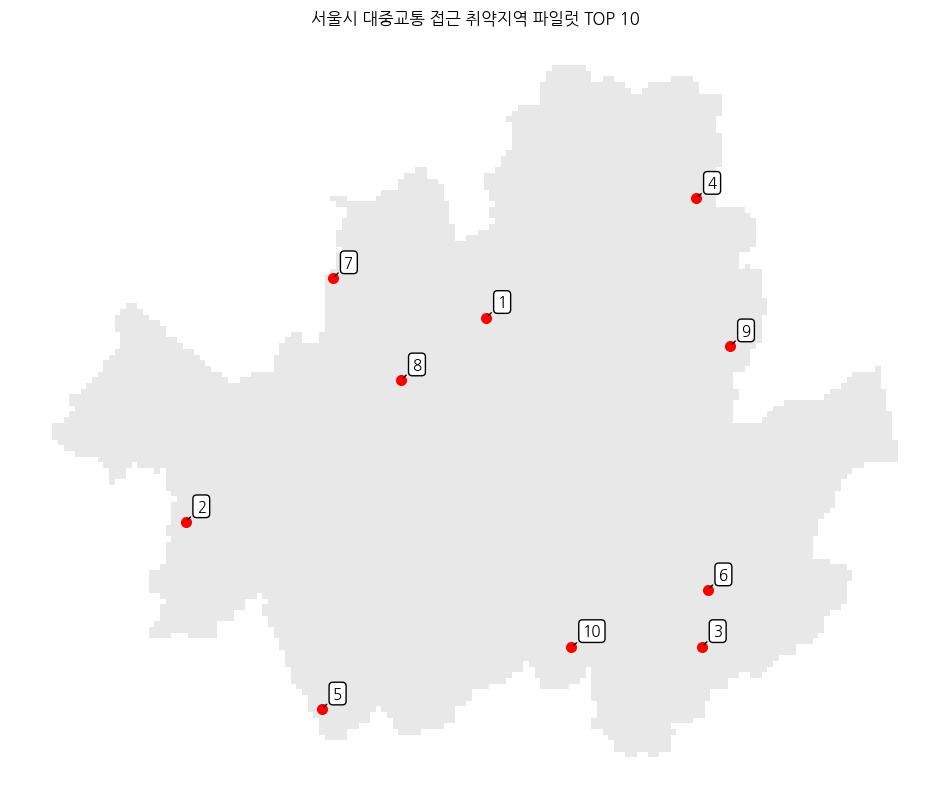

In [327]:
# 서울 전체 지도에 최종 TOP 10 후보의 위치와 취약순위를 표시
fig, ax = plt.subplots(figsize=(12, 12))

# 서울 전체 배경
seoul.plot(
    ax=ax,
    color='lightgray',
    edgecolor='none',
    alpha=0.5
)

# 새 TOP 10 위치 + 순위
for idx, row in top10_unique.iterrows():
    center = row.geometry.centroid

    ax.plot(
        center.x,
        center.y,
        marker='o',
        markersize=7,
        color='red'
    )

    ax.annotate(
        str(row['순위']),
        xy=(center.x, center.y),
        xytext=(8, 8),
        textcoords='offset points',
        fontsize=11,
        fontweight='bold',
        bbox=dict(
            facecolor='white',
            edgecolor='black',
            boxstyle='round,pad=0.25'
        ),
        arrowprops=dict(
            arrowstyle='-',
            color='black'
        )
    )

ax.set_title('서울시 대중교통 접근 취약지역 파일럿 TOP 10')
ax.axis('off')

plt.show()

## 17. 파일럿 분석 해석 및 한계

이번 분석은 2026년 9월 7일 하루의 생활인구를 이용해
대중교통 접근 취약지역 분석 방법이 정상적으로 작동하는지 확인한 파일럿 분석이다.

현재 분석에서는 다음과 같은 잠정 기준을 사용하였다.

- 생활인구 상위 25% 지역을 분석 후보로 선정
- 버스정류장 접근권: 격자 중심 반경 500m
- 철도역 접근권: 격자 중심 반경 1km
- 버스정류장 수, 버스 거리, 철도역 수, 철도 거리의 가중치: 각각 25%
- 최종 후보 간 공간 중복 제거 기준: 중심점 간 1km
- 거리 지표는 실제 보행경로가 아닌 직선거리 사용
- 생활인구의 비공개·결측값은 NaN으로 처리했으며, 최종 TOP 10 격자에는 비공개·결측값이 없음을 확인하였다. 다만 전체 후보군 일부에는 비공개값이 존재하므로, 향후 1년치 본 분석에서는 결측값 처리방식을 추가로 검토할 필요가 있다.

따라서 현재 결과를 서울의 확정적인 대중교통 취약지역 순위로 해석해서는 안 된다.

향후 1년치 생활인구를 이용해 평일·주말 및 시간대별 수요를 분석하고,
버스 노선 수와 운행빈도, 실제 보행경로 등을 추가하여 최종 후보지역을 검증할 예정이다.